# Regularizing DG1 bias, using intergenic regions

In this notebook, we are going to examine intergenic regions, and determine if we can correct bias by constraining that these regions should be unchanging and identical across mother and daughter branches.

Without correction, there is a bias towards DG1 at all kappa values until CG1==DG1.

Procedure:
1. Select a small window in which iteration can be performed quickly.
2. Compute the difference in occupancy and entropy between the two phases
3. Determine a scaling value for regularization that can equalize these metrics between these two phases. 
4. Determine if a scaling vector is appropriate.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [190]:
from src.chromatin_model import ChromatinModel
from src.chromatin_deconvolution_solver import dummy_N_frep_b, ChromatinDeconvolveSolver
from src.sgd import get_orfname
from src.sgd import read_nondubious_genes_dataset
from src.chromatin_deconvolution_solver import ChromatinDeconvolveSolver

genes = read_nondubious_genes_dataset()

def load_solver_gene(gene_name, subset=True, window=200):
    orfname = get_orfname(gene_name)

    gene = genes.loc[orfname]
    tss = gene.TSS
    chrom = gene.chr
    return load_solver_region(chrom, tss, subset=subset, window=window)

In [11]:

def load_solver_region(chrom, mid, subset=True, window=200):
    
    from src.config import load_default_chrom_configs

    config1, _ = load_default_chrom_configs('distinct')

    win_2 = window//2
    
    mnase_span = mid-win_2, mid+win_2

    chromatin_model = ChromatinModel(config1)
    chromatin_model.load_mnase_span(chrom=chrom, mnase_span=mnase_span)

    N, frep, b = dummy_N_frep_b(config1)
    
    if subset:
        G_values, highest_Gs = subset_select_highest_G_indices(chromatin_model.G)
    else:
        G_values = chromatin_model.G

    chromatin_solver = ChromatinDeconvolveSolver(config1, G_values, N, b, frep)
    chromatin_solver.chromatin_model = chromatin_model
    return chromatin_solver

In [158]:
config1, _ = load_default_chrom_configs('distinct')
i_indices = config1.get_Hpositions_for_branch('i')
t_indices = config1.get_Hpositions_for_branch('t')
b_indices = config1.get_Hpositions_for_branch('b')

cg1_indices = config1.get_Hpositions_for_phase('CG1')
dg1_indices = config1.get_Hpositions_for_phase('DG1')

todo: Loading testing config from replication deconvolution


In [202]:
window = 400

chromatin_solver_hm = load_solver_region(4, 620908, subset=False, window=window)
chromatin_solver_gene = load_solver_gene('DSE1', subset=False, window=window)

todo: Loading testing config from replication deconvolution
Loading chromosome reads: 4
Applying a normalization for length distribution
todo: Loading testing config from replication deconvolution
Loading chromosome reads: 5
Applying a normalization for length distribution


In [203]:
kappa = 0.001
gamma = 0.0078

In [204]:
from src.chromatin_deconvolution_solver import plot_branches
from src.helpers import calc_entropy

F_example = chromatin_solver_hm.deconvolve_G_iteratively(gamma=gamma, kappa=kappa,
                                                   verbose=True)
entropy_F = np.array([calc_entropy(F_example[i]) for i in range(F_example.shape[0])])

0/1040 - 00:00:00.002
500/1040 - 00:00:32.271
1000/1040 - 00:01:24.546
Completed - 00:01:25.311


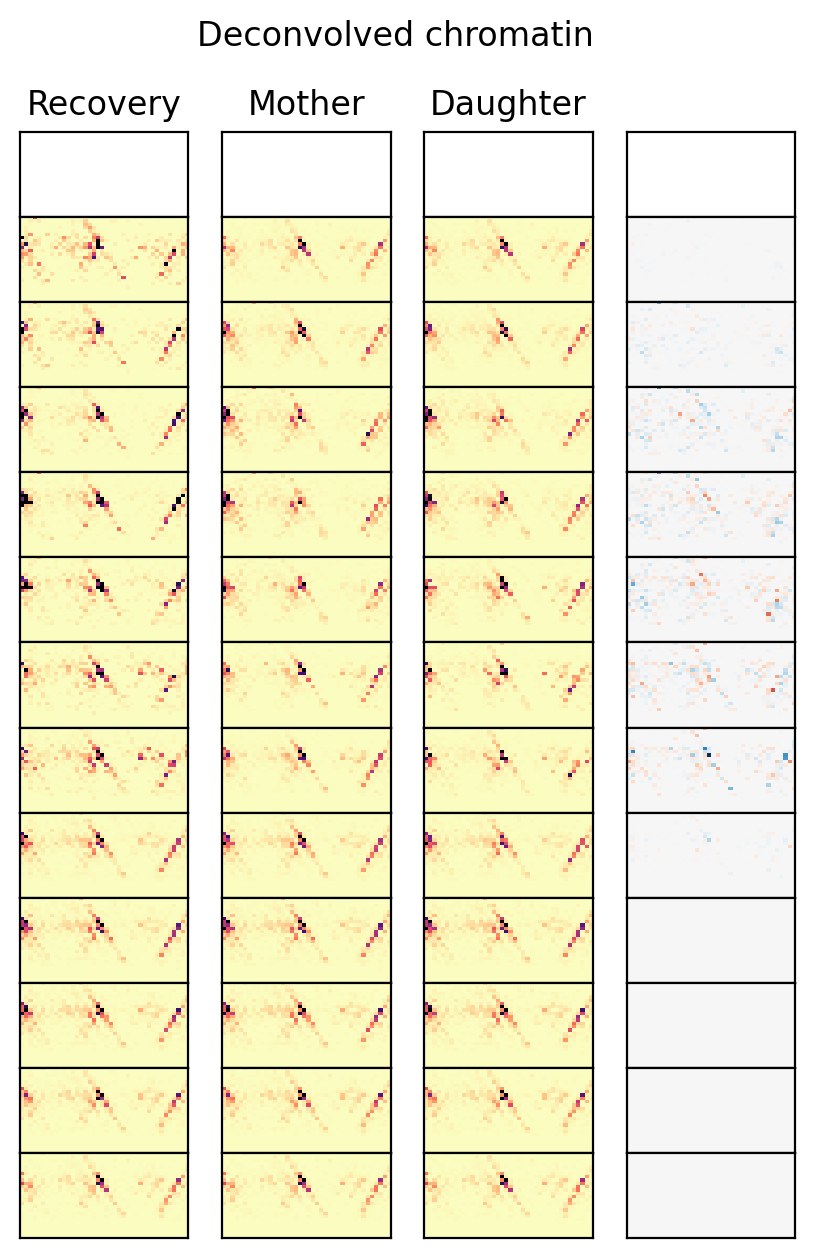

In [210]:
fig = plot_branches(config1, chromatin_solver_hm.chromatin_model.chr, 
              chromatin_solver_hm.chromatin_model.mnase_span, F_example)

In [ ]:
F_gene = chromatin_solver_gene.deconvolve_G_iteratively(gamma=gamma, kappa=kappa,
                                                   verbose=True)

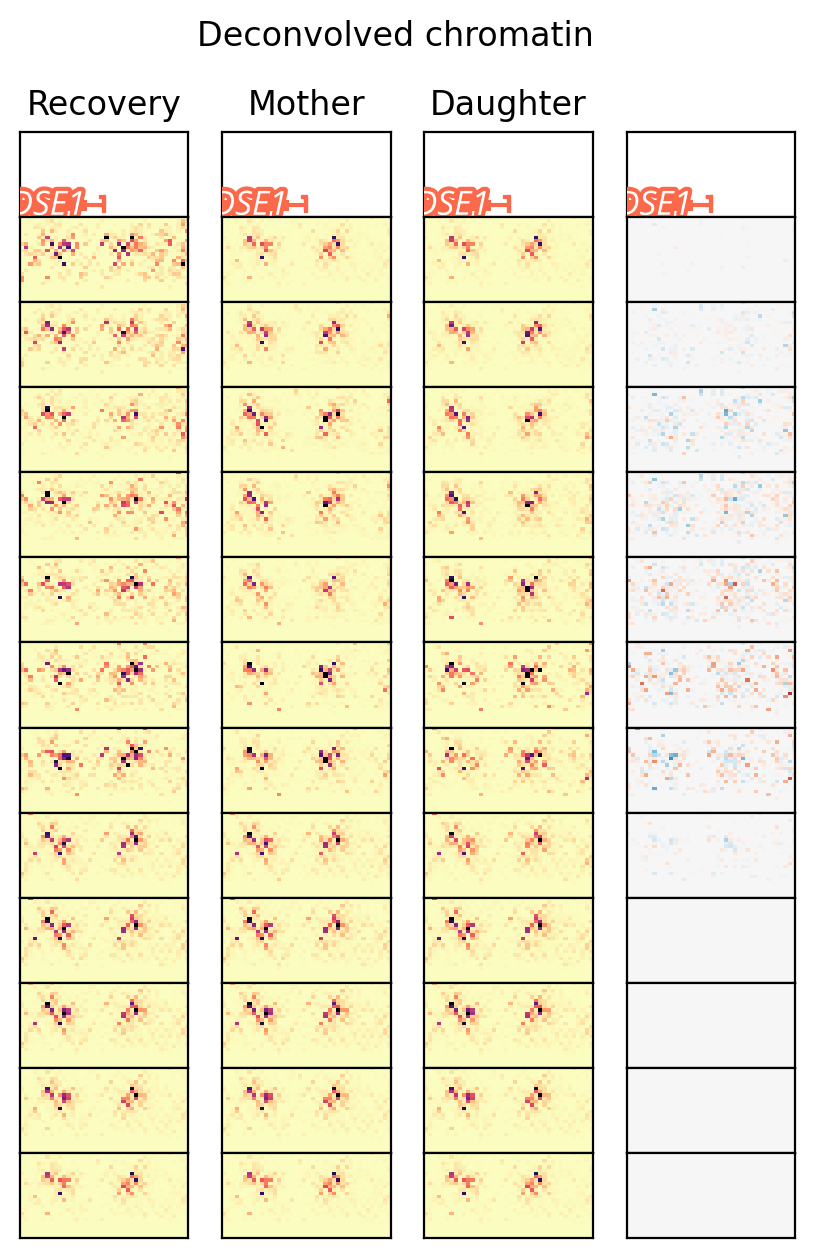

In [211]:
fig = plot_branches(config1, chromatin_solver_gene.chromatin_model.chr, 
              chromatin_solver_gene.chromatin_model.mnase_span, F_gene)